# 05 — Challenger Model: XGBoost

Gradient-boosted tree model with MLflow experiment tracking.
Trained with class-weight adjustment for the 8% default rate
and credit-risk-specific evaluation metrics (Gini, KS).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import xgboost as xgb
import shap
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from evaluate import compute_gini, compute_ks_statistic

sns.set_style("whitegrid")
%matplotlib inline

c:\Users\Eric\credit-scorecard-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]

feature_cols = [c for c in df.columns if c not in exclude]
X = df[feature_cols].copy()
y = df[target]

# Encode categoricals
for col in X.select_dtypes(include=["object", "category"]).columns:
    X[col] = X[col].astype("category").cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (246008, 197)  |  Test: (61503, 197)


## Cross-Validated Training with MLflow

In [3]:
mlflow.set_experiment("credit_risk_challenger")

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "n_estimators": 500,
    "scale_pos_weight": float(pos_weight),
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42,
}

with mlflow.start_run(run_name="xgboost_v1"):
    mlflow.log_params(params)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_fold_tr = X_train.iloc[train_idx]
        y_fold_tr = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_fold_tr, y_fold_tr,
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False,
        )
        
        y_prob = model.predict_proba(X_fold_val)[:, 1]
        auc = roc_auc_score(y_fold_val, y_prob)
        gini = compute_gini(y_fold_val, y_prob)
        ks = compute_ks_statistic(y_fold_val, y_prob)
        
        cv_results.append({"fold": fold, "auc": auc, "gini": gini, "ks": ks})
        print(f"Fold {fold}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    
    mlflow.log_metric("mean_auc", np.mean([r["auc"] for r in cv_results]))
    mlflow.log_metric("mean_gini", np.mean([r["gini"] for r in cv_results]))
    mlflow.log_metric("mean_ks", np.mean([r["ks"] for r in cv_results]))
    
    print(f"\nMean AUC:  {np.mean([r['auc'] for r in cv_results]):.4f}")
    print(f"Mean Gini: {np.mean([r['gini'] for r in cv_results]):.4f}")
    print(f"Mean KS:   {np.mean([r['ks'] for r in cv_results]):.4f}")

2026/02/28 22:10:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/28 22:10:56 INFO mlflow.store.db.utils: Updating database tables
2026/02/28 22:10:58 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_challenger' does not exist. Creating a new experiment.


Fold 0: AUC=0.7790  Gini=0.5579  KS=0.4212
Fold 1: AUC=0.7799  Gini=0.5598  KS=0.4237
Fold 2: AUC=0.7834  Gini=0.5669  KS=0.4314
Fold 3: AUC=0.7835  Gini=0.5671  KS=0.4355
Fold 4: AUC=0.7797  Gini=0.5593  KS=0.4197

Mean AUC:  0.7811
Mean Gini: 0.5622
Mean KS:   0.4263


## Optuna Hyperparameter Tuning

Systematic hyperparameter search using Optuna's TPE sampler. Objective: maximize AUC-ROC on 3-fold CV. This replaces manual grid search and typically finds better configurations in fewer trials.

In [5]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

neg_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': neg_weight,
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='xgb_credit_risk')
study.optimize(objective, n_trials=10, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

# Retrain with best params
best_params = study.best_params
best_params.update({
    'scale_pos_weight': neg_weight,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
})
xgb_best = xgb.XGBClassifier(**best_params)
xgb_best.fit(X_train, y_train)
y_prob = xgb_best.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print(f"\nOptuna-tuned XGBoost AUC on test set: {roc_auc_score(y_test, y_prob):.4f}")

Best trial: 2. Best value: 0.779162: 100%|██████████| 10/10 [04:00<00:00, 24.01s/it]



Best AUC: 0.7792
Best params:
   n_estimators: 400
   max_depth: 4
   learning_rate: 0.04665924529702313
   subsample: 0.8067056477392129
   colsample_bytree: 0.7659101632549863
   min_child_weight: 5
   reg_alpha: 0.5441499867627185
   reg_lambda: 0.0033402748365017505

Optuna-tuned XGBoost AUC on test set: 0.7823


## Final Model — Train on Full Training Set

In [6]:
final_params = {k: v for k, v in best_params.items() if k != "early_stopping_rounds"}
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train, verbose=False)

# Hold-out evaluation
y_prob_test = final_model.predict_proba(X_test)[:, 1]
print(f"Hold-out AUC:  {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"Hold-out Gini: {compute_gini(y_test, y_prob_test):.4f}")
print(f"Hold-out KS:   {compute_ks_statistic(y_test, y_prob_test):.4f}")

Hold-out AUC:  0.7823
Hold-out Gini: 0.5646
Hold-out KS:   0.4273


## SHAP Explainability

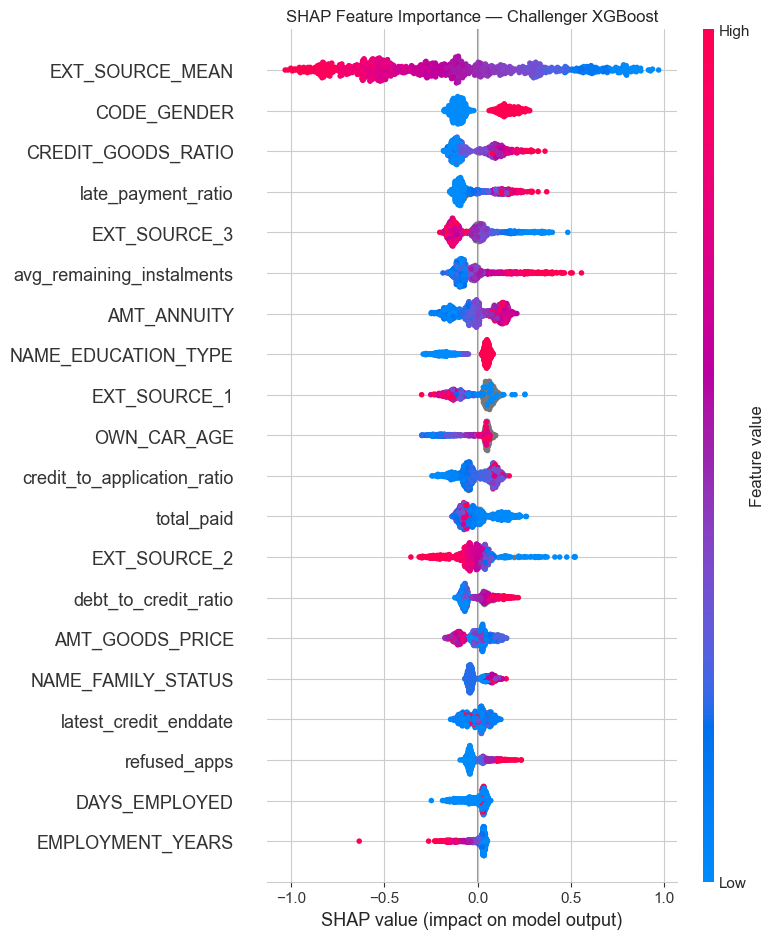

In [7]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])  # subset for speed

# Global importance
shap.summary_plot(shap_values, X_test.iloc[:1000], max_display=20, show=False)
plt.title("SHAP Feature Importance — Challenger XGBoost")
plt.tight_layout()
plt.show()

Predicted default prob: 0.3619
Actual: Non-default


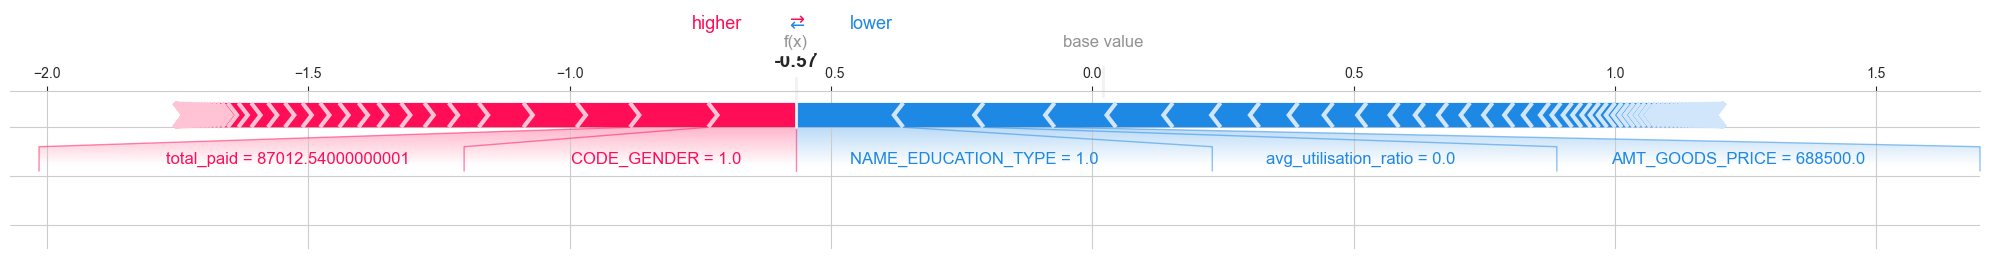

In [8]:
# Single prediction explanation
idx = 0
print(f"Predicted default prob: {y_prob_test[idx]:.4f}")
print(f"Actual: {'Default' if y_test.iloc[idx] == 1 else 'Non-default'}")

shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx],
                matplotlib=True, show=False)
plt.tight_layout()
plt.show()

## SHAP Waterfall Plot — Single Prediction Explanation

Waterfall plot shows how each feature pushes the prediction from the base value (population average) to the final output. This is the format used for ECOA adverse action notices.

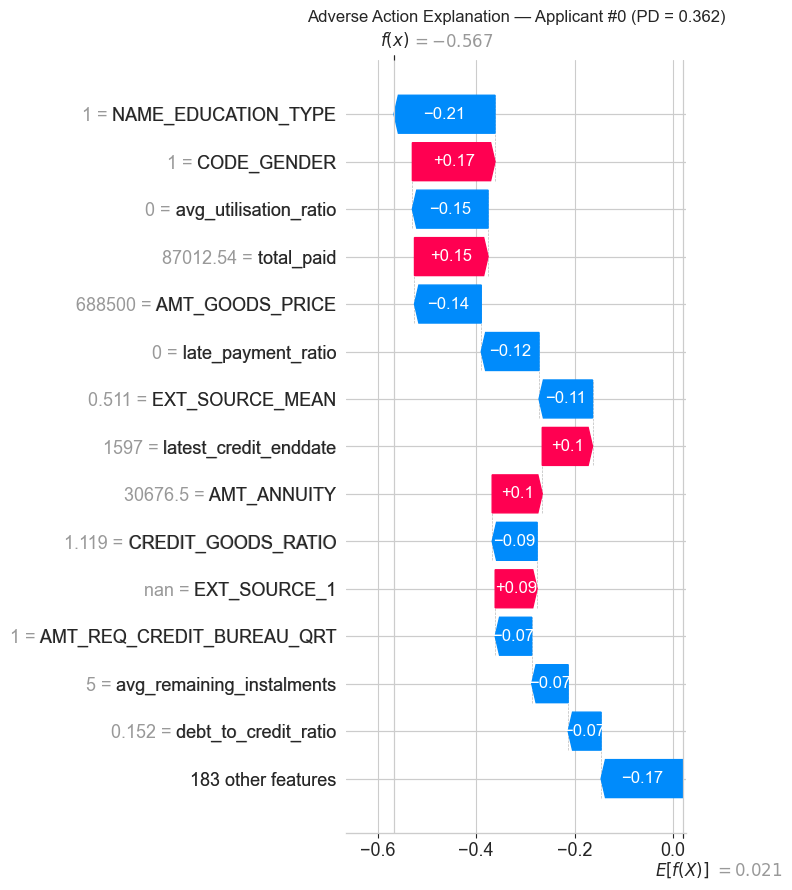

In [9]:
# SHAP waterfall plot for a single high-risk prediction
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# Find a high-risk example (predicted PD > 0.3)
y_prob_test = final_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.where(y_prob_test > 0.3)[0]
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

fig = plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_values[sample_idx], max_display=15, show=False)
plt.title(f'Adverse Action Explanation — Applicant #{sample_idx} (PD = {y_prob_test[sample_idx]:.3f})')
plt.tight_layout()
plt.show()

## KS Chart — Kolmogorov-Smirnov Visualization

The KS statistic measures the maximum separation between cumulative distributions of good and bad loans. A higher KS means better risk ranking. The chart below shows where the model achieves maximum discrimination.

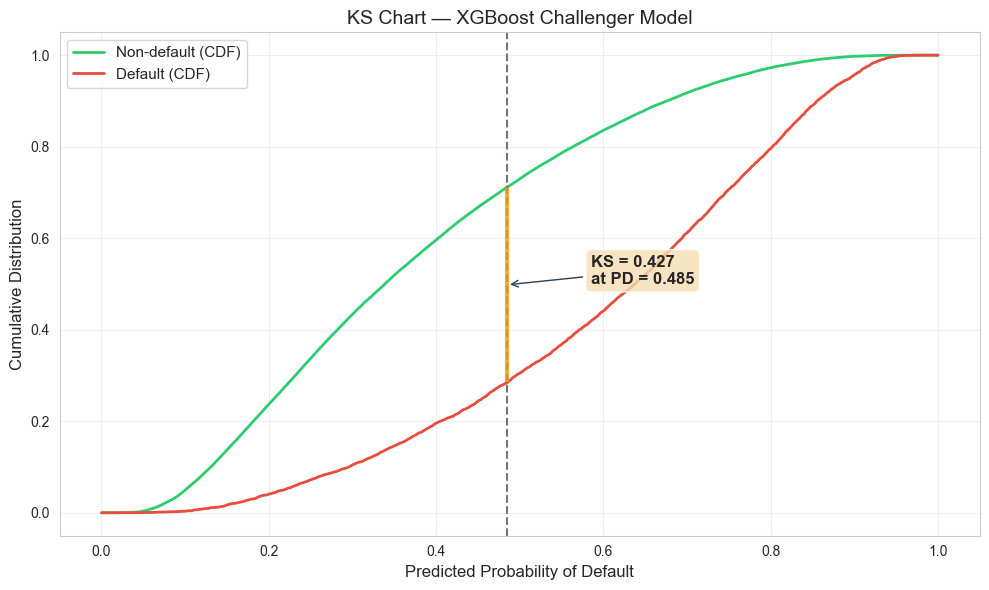

KS Statistic: 0.4270 (threshold: > 0.30 PASS)


In [10]:
# KS Chart — cumulative distribution of scores by class
y_prob_test = final_model.predict_proba(X_test)[:, 1]
scores_good = np.sort(y_prob_test[y_test == 0])
scores_bad = np.sort(y_prob_test[y_test == 1])

# CDF for both classes
thresholds = np.linspace(0, 1, 500)
cdf_good = np.searchsorted(scores_good, thresholds) / len(scores_good)
cdf_bad = np.searchsorted(scores_bad, thresholds) / len(scores_bad)

# Find max separation
ks_idx = np.argmax(np.abs(cdf_bad - cdf_good))
ks_stat = np.abs(cdf_bad[ks_idx] - cdf_good[ks_idx])
ks_threshold = thresholds[ks_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, cdf_good, label='Non-default (CDF)', color='#2ecc71', linewidth=2)
ax.plot(thresholds, cdf_bad, label='Default (CDF)', color='#e74c3c', linewidth=2)
ax.axvline(x=ks_threshold, color='#2c3e50', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks_stat:.3f}\nat PD = {ks_threshold:.3f}',
            xy=(ks_threshold, (cdf_good[ks_idx] + cdf_bad[ks_idx]) / 2),
            xytext=(ks_threshold + 0.1, 0.5),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Shade KS region
ax.fill_betweenx([cdf_good[ks_idx], cdf_bad[ks_idx]], ks_threshold, ks_threshold,
                 alpha=0.3, color='#f39c12')
ax.vlines(ks_threshold, cdf_good[ks_idx], cdf_bad[ks_idx], colors='#f39c12', linewidth=3, alpha=0.8)

ax.set_xlabel('Predicted Probability of Default', fontsize=12)
ax.set_ylabel('Cumulative Distribution', fontsize=12)
ax.set_title('KS Chart — XGBoost Challenger Model', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"KS Statistic: {ks_stat:.4f} (threshold: {'> 0.30 PASS' if ks_stat > 0.30 else '< 0.30 WARN'})")

In [11]:
# Save
import pathlib
models_dir = pathlib.Path("../models")
joblib.dump(final_model, models_dir / "xgboost_challenger.pkl")
print("Challenger model saved.")

Challenger model saved.
